# Actividad 2 — Modelos de regresión para estimar el desempeño académico

## Student Performance Factors Dataset

---

### 1.1 Ficha de identificación del dataset

| Campo | Detalle |
|---|---|
| **Nombre del dataset** | Student Performance Factors Dataset |
| **Autor** | Mosap Abdel-Ghany |
| **Fuente** | Kaggle |
| **Liga de acceso** | https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset |
| **Fecha de consulta** | 17 de agosto de 2026 |
| **Última actualización en Kaggle** | 16 de octubre de 2025 |
| **Licencia** | CC0: Public Domain |
| **Origen de los datos** | Datos sintéticos generados con fines educativos |
| **Volumen** | 6,607 registros × 20 variables |

**Referencia en formato APA:**

> Abdel-Ghany, M. (2025). *Student Performance Factors Dataset* [Conjunto de datos]. Kaggle.
> https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset

---

### 1.2 Contexto

El conjunto reúne factores **académicos, personales, familiares y escolares** de estudiantes de
nivel medio superior, junto con la calificación obtenida en su examen final. Agrupa tres familias
de variables: conductuales (horas de estudio, asistencia, sueño), contextuales (ingreso familiar,
acceso a recursos, escolaridad de los padres) y actitudinales (motivación, influencia de pares,
calidad docente).

Se trata de **datos sintéticos**, generados artificialmente para fines didácticos. Esta condición
no impide desarrollar el ejercicio de modelado, pero sí limita la extrapolación de cualquier
hallazgo a estudiantes reales.

### 1.3 Qué representa cada registro

Cada **fila corresponde a un estudiante individual**. Las 19 primeras columnas describen sus
características y hábitos previos al examen; la última registra el resultado obtenido. No existe
columna de identificador: cada renglón es una observación independiente.

### 1.4 Variable objetivo

**`Exam_Score`** — calificación obtenida en el examen final, medida en puntos sobre 100. Es la
única variable que representa un **resultado** y no una condición previa del estudiante, y es la
que el autor declara como *target* en la ficha de Kaggle.

Al tratarse de una variable **numérica continua**, la tarea corresponde a un problema de
**regresión supervisada**.

### 1.5 Pregunta predictiva que guía el análisis

> **¿En qué medida las características académicas, personales y escolares de los estudiantes
> permiten estimar su puntaje de examen mediante modelos de regresión?**

De esta pregunta se derivan tres preguntas operativas que el notebook responderá con evidencia:

1. ¿Un modelo entrenado supera a una predicción constante (la media)?
2. ¿Qué variables aportan mayor capacidad predictiva?
3. ¿El error del modelo es lo bastante pequeño para apoyar decisiones académicas reales?

### 1.6 Relación con la Actividad 1

La Actividad 1 dejó el conjunto diagnosticado, limpio y con un flujo de transformaciones definido.
Esta actividad **retoma ese trabajo** para entrenar y evaluar modelos. En la sección 2.2 se explica
en detalle qué se reutiliza y qué se reconstruye, junto con la razón técnica de esa decisión.

---

## 2. Preparación del entorno y carga de datos

In [1]:
# Manejo de datos
import pandas as pd
import numpy as np
import glob, os, warnings

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Division de datos y validacion
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Modelos
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Metricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Semilla global: garantiza que todo el notebook sea reproducible
SEMILLA = 42
np.random.seed(SEMILLA)

print('Librerias cargadas correctamente.')
print(f'Semilla fija establecida: {SEMILLA}')

Librerias cargadas correctamente.
Semilla fija establecida: 42


### 2.1 Verificación del archivo preparado en la Actividad 1

La rúbrica solicita comprobar que el archivo generado en la actividad anterior **pueda cargarse sin
errores** y documentar las transformaciones que ya se le aplicaron. Eso se verifica a continuación.

In [2]:
ruta_act1 = None
for patron in ['/content/*procesado*.csv', '*procesado*.csv', '../*procesado*.csv']:
    encontrados = glob.glob(patron)
    if encontrados:
        ruta_act1 = encontrados[0]
        break

if ruta_act1:
    df_act1 = pd.read_csv(ruta_act1)
    print('VERIFICACION DEL ARCHIVO DE LA ACTIVIDAD 1')
    print('=' * 66)
    print(f'Archivo            : {os.path.basename(ruta_act1)}')
    print(f'1. Carga sin errores        : OK')
    print(f'2. Dimensiones              : {df_act1.shape[0]:,} x {df_act1.shape[1]}')
    print(f'3. Variable objetivo presente: '
          f'{"OK" if "Exam_Score" in df_act1.columns else "NO"}')
    print(f'4. Valores faltantes        : {int(df_act1.isna().sum().sum())}')
    print(f'5. Todas numericas          : '
          f'{"OK" if df_act1.select_dtypes(include=np.number).shape[1] == df_act1.shape[1] else "NO"}')
    print('\nTransformaciones ya aplicadas en la Actividad 1:')
    print('  - Imputacion por moda de 235 valores faltantes en 3 variables cualitativas')
    print('  - Recorte de 1 valor imposible en Exam_Score (101 -> 100)')
    print('  - Codificacion ordinal de 8 variables con jerarquia natural')
    print('  - One-Hot Encoding de 5 variables nominales binarias')
    print('  - Escalamiento de 6 variables numericas con StandardScaler')
    print('  - Exam_Score conservada en su escala original (sin transformar)')
else:
    print('No se localizo el archivo de la Actividad 1.')
    print('No es indispensable: el notebook parte del dataset original.')

VERIFICACION DEL ARCHIVO DE LA ACTIVIDAD 1
Archivo            : StudentPerformanceFactors_procesado.csv
1. Carga sin errores        : OK
2. Dimensiones              : 6,607 x 20
3. Variable objetivo presente: OK
4. Valores faltantes        : 0
5. Todas numericas          : OK

Transformaciones ya aplicadas en la Actividad 1:
  - Imputacion por moda de 235 valores faltantes en 3 variables cualitativas
  - Recorte de 1 valor imposible en Exam_Score (101 -> 100)
  - Codificacion ordinal de 8 variables con jerarquia natural
  - One-Hot Encoding de 5 variables nominales binarias
  - Escalamiento de 6 variables numericas con StandardScaler
  - Exam_Score conservada en su escala original (sin transformar)


### 2.2 Por qué el modelado parte del dataset original y no del archivo ya transformado

Esta es una **decisión metodológica deliberada**, y conviene justificarla porque a primera vista
parecería más eficiente reutilizar el archivo ya preparado.

El archivo `StudentPerformanceFactors_procesado.csv` se generó aplicando `fit_transform()` sobre
**la totalidad** del conjunto. Eso significa que la media y la desviación estándar que usó
`StandardScaler`, así como la moda que usó el imputador, se calcularon **incluyendo los registros
que en esta actividad formarán el conjunto de prueba**.

Si se entrenara con ese archivo, se incurriría exactamente en la **fuga de información** que la
Actividad 1 advirtió en su sección 10.2: el conjunto de prueba dejaría de ser una simulación
honesta de datos nunca vistos, y las métricas resultantes serían optimistas y engañosas.

Por lo tanto, el procedimiento correcto es:

1. Partir del **dataset original**.
2. Aplicar únicamente la **limpieza** (imputación y corrección de valores imposibles), que es
   independiente de la partición.
3. **Dividir** en entrenamiento y prueba.
4. Ajustar el preprocesamiento **sólo con entrenamiento**, dentro de un `Pipeline`.

El archivo de la Actividad 1 conserva así su valor como entregable verificado y como documentación
del flujo de transformaciones, pero **no se emplea como insumo de entrenamiento**.

In [3]:
# Carga del dataset original
candidatos = (glob.glob('/content/*.zip') + glob.glob('*.zip')
              + glob.glob('/content/*.csv') + glob.glob('*.csv'))
candidatos = [c for c in candidatos if 'procesado' not in c.lower()]

if not candidatos:
    raise FileNotFoundError('Sube el zip o csv de Kaggle al entorno.')

ruta_original = candidatos[0]
df = pd.read_csv(ruta_original)

print(f'Archivo cargado : {os.path.basename(ruta_original)}')
print(f'Dimensiones     : {df.shape[0]:,} registros x {df.shape[1]} variables')

Archivo cargado : StudentPerformanceFactors_original.zip
Dimensiones     : 6,607 registros x 20 variables


---

## 3. Revisión inicial de la estructura

In [4]:
print('=' * 66)
print('ESTRUCTURA GENERAL')
print('=' * 66)
print(f'Registros : {df.shape[0]:,}')
print(f'Variables : {df.shape[1]}')

resumen = pd.DataFrame({
    'Tipo'      : df.dtypes.astype(str),
    'No_nulos'  : df.notna().sum(),
    'Faltantes' : df.isna().sum(),
    'Pct_falt'  : (df.isna().sum() / len(df) * 100).round(2),
    'Unicos'    : df.nunique(),
}).reset_index().rename(columns={'index': 'Variable'})

print(f'\nDuplicados : {int(df.duplicated().sum())}')
print(f'Faltantes totales: {int(df.isna().sum().sum())}')
resumen

ESTRUCTURA GENERAL
Registros : 6,607
Variables : 20

Duplicados : 0
Faltantes totales: 235


,Variable,Tipo,No_nulos,Faltantes,Pct_falt,Unicos
0,Hours_Studied,int64,6607,0,0.00,41
1,Attendance,int64,6607,0,0.00,41
2,Parental_Involvement,object,6607,0,0.00,3
3,Access_to_Resources,object,6607,0,0.00,3
4,Extracurricular_Activities,object,6607,0,0.00,2
5,Sleep_Hours,int64,6607,0,0.00,7
6,Previous_Scores,int64,6607,0,0.00,51
7,Motivation_Level,object,6607,0,0.00,3
8,Internet_Access,object,6607,0,0.00,2
9,Tutoring_Sessions,int64,6607,0,0.00,9


In [5]:
print('MUESTRA DE REGISTROS')
df.head()

MUESTRA DE REGISTROS


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### 3.1 Limpieza mínima necesaria para el modelado

Se aplica **únicamente** la limpieza indispensable, replicando los criterios ya justificados en la
Actividad 1. No se repite el diagnóstico completo porque ya fue documentado allí.

In [6]:
df_limpio = df.copy()
registros_iniciales = len(df_limpio)
faltantes_iniciales = int(df_limpio.isna().sum().sum())

# --- Paso 1: espacios sobrantes en variables de texto ---
for col in df_limpio.select_dtypes(include='object').columns:
    df_limpio[col] = df_limpio[col].str.strip()

# --- Paso 2: duplicados ---
antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
print(f'PASO 1-2  Espacios normalizados; duplicados eliminados: {antes - len(df_limpio)}')

# --- Paso 3: valores faltantes ---
# Se imputan aqui porque son variables cualitativas con <2 % de nulos y el
# criterio (moda) no depende de la particion. La imputacion tambien queda
# incluida en el Pipeline, de modo que el flujo es reproducible ante datos nuevos.
print('\nPASO 3  Imputacion de faltantes:')
for col in df_limpio.columns[df_limpio.isna().any()].tolist():
    n = int(df_limpio[col].isna().sum())
    valor = (df_limpio[col].mode()[0] if df_limpio[col].dtype == 'object'
             else df_limpio[col].median())
    df_limpio[col] = df_limpio[col].fillna(valor)
    print(f'   {col:28s}: {n:3d} nulos -> "{valor}"')

# --- Paso 4: valores imposibles en la variable objetivo ---
fuera = int((df_limpio['Exam_Score'] > 100).sum())
if fuera > 0:
    print(f'\nPASO 4  {fuera} valor(es) de Exam_Score > 100 recortados a 100')
    print(f'   rango antes  : [{df_limpio.Exam_Score.min()}, {df_limpio.Exam_Score.max()}]')
    df_limpio['Exam_Score'] = df_limpio['Exam_Score'].clip(upper=100)
    print(f'   rango despues: [{df_limpio.Exam_Score.min()}, {df_limpio.Exam_Score.max()}]')

print(f'\n{"=" * 66}')
print(f'Registros : {registros_iniciales:,} -> {len(df_limpio):,} '
      f'({len(df_limpio) / registros_iniciales * 100:.2f} % conservado)')
print(f'Faltantes : {faltantes_iniciales} -> {int(df_limpio.isna().sum().sum())}')

PASO 1-2  Espacios normalizados; duplicados eliminados: 0

PASO 3  Imputacion de faltantes:


   Teacher_Quality             :  78 nulos -> "Medium"
   Parental_Education_Level    :  90 nulos -> "High School"
   Distance_from_Home          :  67 nulos -> "Near"

PASO 4  1 valor(es) de Exam_Score > 100 recortados a 100
   rango antes  : [55, 101]
   rango despues: [55, 100]

Registros : 6,607 -> 6,607 (100.00 % conservado)
Faltantes : 235 -> 0


---

## 4. Exploración de la variable objetivo y de sus predictores

In [7]:
objetivo = 'Exam_Score'
y_serie = df_limpio[objetivo]

print('=' * 66)
print(f'ESTADISTICAS DESCRIPTIVAS DE {objetivo}')
print('=' * 66)
print(f'Conteo              : {len(y_serie):,}')
print(f'Media               : {y_serie.mean():.2f}')
print(f'Mediana             : {y_serie.median():.2f}')
print(f'Desviacion estandar : {y_serie.std():.2f}')
print(f'Minimo / Maximo     : {y_serie.min():.0f} / {y_serie.max():.0f}')
print(f'Q1 / Q3 / RIC       : {y_serie.quantile(.25):.0f} / '
      f'{y_serie.quantile(.75):.0f} / {y_serie.quantile(.75) - y_serie.quantile(.25):.0f}')
print(f'Asimetria           : {y_serie.skew():.3f}')
print(f'Curtosis            : {y_serie.kurtosis():.3f}')
print(f'\nDato clave para el modelado:')
print(f'  El 50 % central de los alumnos esta entre {y_serie.quantile(.25):.0f} y '
      f'{y_serie.quantile(.75):.0f} puntos.')
print(f'  Cualquier modelo util debe lograr un error MENOR que esa amplitud.')

ESTADISTICAS DESCRIPTIVAS DE Exam_Score
Conteo              : 6,607
Media               : 67.24
Mediana             : 67.00
Desviacion estandar : 3.89
Minimo / Maximo     : 55 / 100
Q1 / Q3 / RIC       : 65 / 69 / 4
Asimetria           : 1.638
Curtosis            : 10.496

Dato clave para el modelado:
  El 50 % central de los alumnos esta entre 65 y 69 puntos.
  Cualquier modelo util debe lograr un error MENOR que esa amplitud.


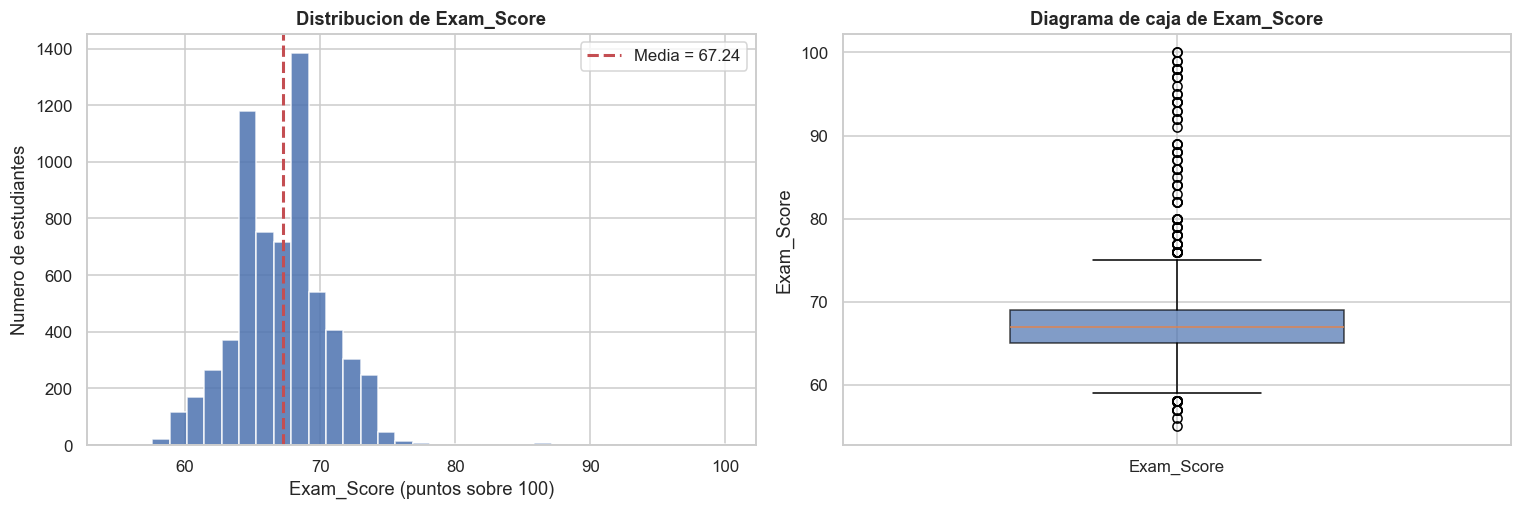

Interpretacion: distribucion muy concentrada (desviacion de solo 3.89 puntos) con cola derecha marcada.
Esto anticipa que la LINEA BASE sera dificil de superar por mucho margen,
y que los alumnos de alto rendimiento seran los mas dificiles de predecir.


In [8]:
# VISUALIZACION 1: distribucion de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].hist(y_serie, bins=35, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(y_serie.mean(), color='#C44E52', linestyle='--', linewidth=2,
                label=f'Media = {y_serie.mean():.2f}')
axes[0].set_title('Distribucion de Exam_Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Exam_Score (puntos sobre 100)')
axes[0].set_ylabel('Numero de estudiantes')
axes[0].legend()

bp = axes[1].boxplot(y_serie, vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#4C72B0'); bp['boxes'][0].set_alpha(0.7)
axes[1].set_title('Diagrama de caja de Exam_Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Exam_Score')
axes[1].set_xticklabels(['Exam_Score'])

plt.tight_layout(); plt.show()

print('Interpretacion: distribucion muy concentrada (desviacion de solo '
      f'{y_serie.std():.2f} puntos) con cola derecha marcada.')
print('Esto anticipa que la LINEA BASE sera dificil de superar por mucho margen,')
print('y que los alumnos de alto rendimiento seran los mas dificiles de predecir.')

In [9]:
# Clasificacion de variables segun su naturaleza
variables_ordinales = {
    'Parental_Involvement'    : ['Low', 'Medium', 'High'],
    'Access_to_Resources'     : ['Low', 'Medium', 'High'],
    'Motivation_Level'        : ['Low', 'Medium', 'High'],
    'Family_Income'           : ['Low', 'Medium', 'High'],
    'Teacher_Quality'         : ['Low', 'Medium', 'High'],
    'Peer_Influence'          : ['Negative', 'Neutral', 'Positive'],
    'Parental_Education_Level': ['High School', 'College', 'Postgraduate'],
    'Distance_from_Home'      : ['Near', 'Moderate', 'Far'],
}
variables_nominales = ['Extracurricular_Activities', 'Internet_Access',
                       'School_Type', 'Learning_Disabilities', 'Gender']
variables_numericas = [c for c in df_limpio.select_dtypes(include=np.number).columns
                       if c != objetivo]

print(f'Numericas ({len(variables_numericas)}): {variables_numericas}')
print(f'Ordinales ({len(variables_ordinales)}): {list(variables_ordinales.keys())}')
print(f'Nominales ({len(variables_nominales)}): {variables_nominales}')

Numericas (6): ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Ordinales (8): ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Parental_Education_Level', 'Distance_from_Home']
Nominales (5): ['Extracurricular_Activities', 'Internet_Access', 'School_Type', 'Learning_Disabilities', 'Gender']


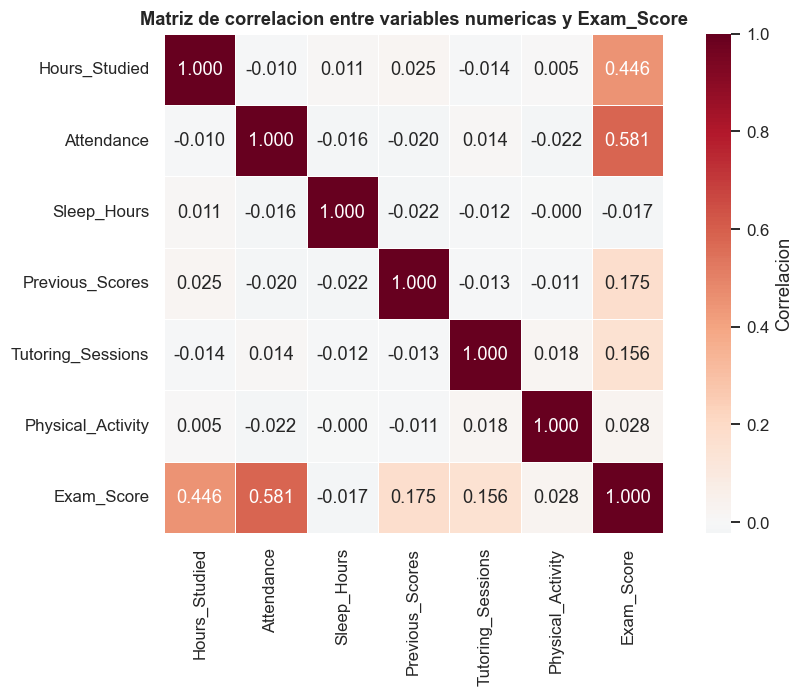

Correlacion de cada variable numerica con Exam_Score:
  Attendance          : +0.581  (FUERTE)
  Hours_Studied       : +0.446  (FUERTE)
  Previous_Scores     : +0.175  (moderada)
  Tutoring_Sessions   : +0.156  (moderada)
  Physical_Activity   : +0.028  (debil)
  Sleep_Hours         : -0.017  (debil)

La correlacion maxima entre dos PREDICTORAS es 0.025
Al ser tan baja, NO hay multicolinealidad: ninguna variable es redundante.


In [10]:
# VISUALIZACION 2: matriz de correlacion
plt.figure(figsize=(9, 6.5))
corr = df_limpio[variables_numericas + [objetivo]].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlacion'})
plt.title('Matriz de correlacion entre variables numericas y Exam_Score',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

corr_obj = corr[objetivo].drop(objetivo).sort_values(ascending=False)
print('Correlacion de cada variable numerica con Exam_Score:')
for v, c in corr_obj.items():
    fuerza = ('FUERTE' if abs(c) > 0.4 else 'moderada' if abs(c) > 0.15 else 'debil')
    print(f'  {v:20s}: {c:+.3f}  ({fuerza})')

print('\nLa correlacion maxima entre dos PREDICTORAS es '
      f'{corr.loc[variables_numericas, variables_numericas].abs().where(~np.eye(len(variables_numericas), dtype=bool)).max().max():.3f}')
print('Al ser tan baja, NO hay multicolinealidad: ninguna variable es redundante.')

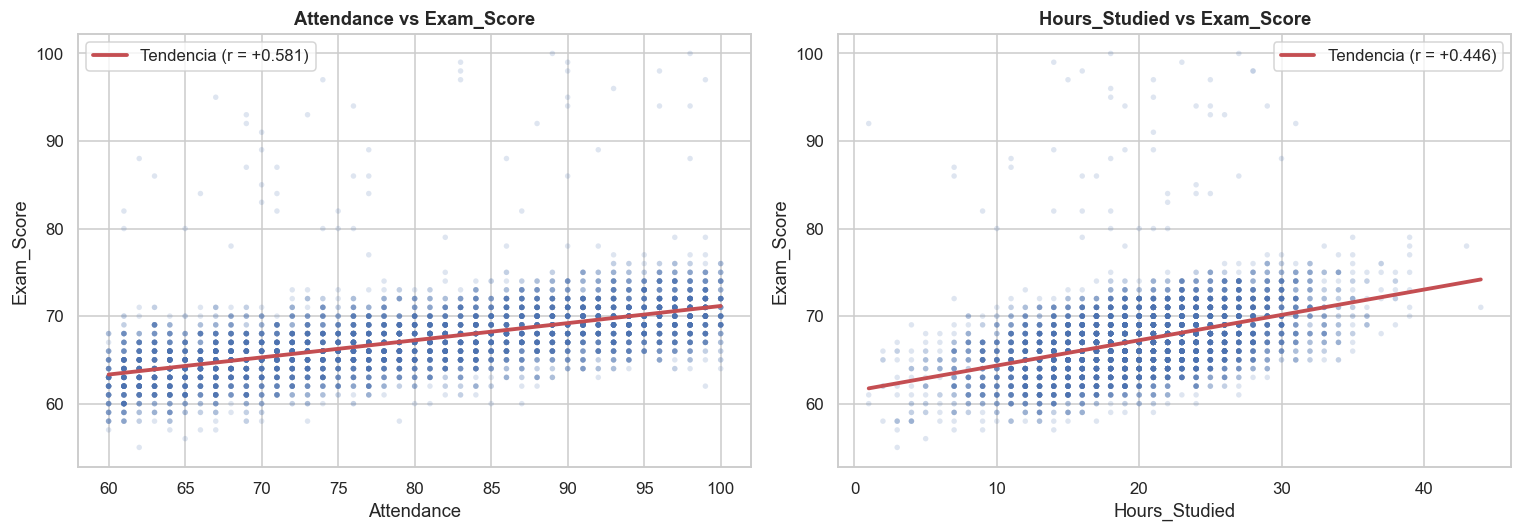

Ambas relaciones son CLARAMENTE LINEALES y crecientes.
Esta observacion es determinante: anticipa que un modelo lineal debe
funcionar bien, y que un modelo mas flexible no necesariamente mejorara.


In [11]:
# VISUALIZACION 3: dispersion de los dos predictores numericos mas correlacionados
top2 = corr_obj.abs().sort_values(ascending=False).head(2).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(top2):
    axes[i].scatter(df_limpio[col], y_serie, alpha=0.18, s=13,
                    color='#4C72B0', edgecolors='none')
    # Linea de tendencia
    z = np.polyfit(df_limpio[col], y_serie, 1)
    xs = np.linspace(df_limpio[col].min(), df_limpio[col].max(), 100)
    axes[i].plot(xs, np.polyval(z, xs), color='#C44E52', linewidth=2.5,
                 label=f'Tendencia (r = {corr_obj[col]:+.3f})')
    axes[i].set_title(f'{col} vs Exam_Score', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam_Score')
    axes[i].legend()

plt.tight_layout(); plt.show()
print('Ambas relaciones son CLARAMENTE LINEALES y crecientes.')
print('Esta observacion es determinante: anticipa que un modelo lineal debe')
print('funcionar bien, y que un modelo mas flexible no necesariamente mejorara.')

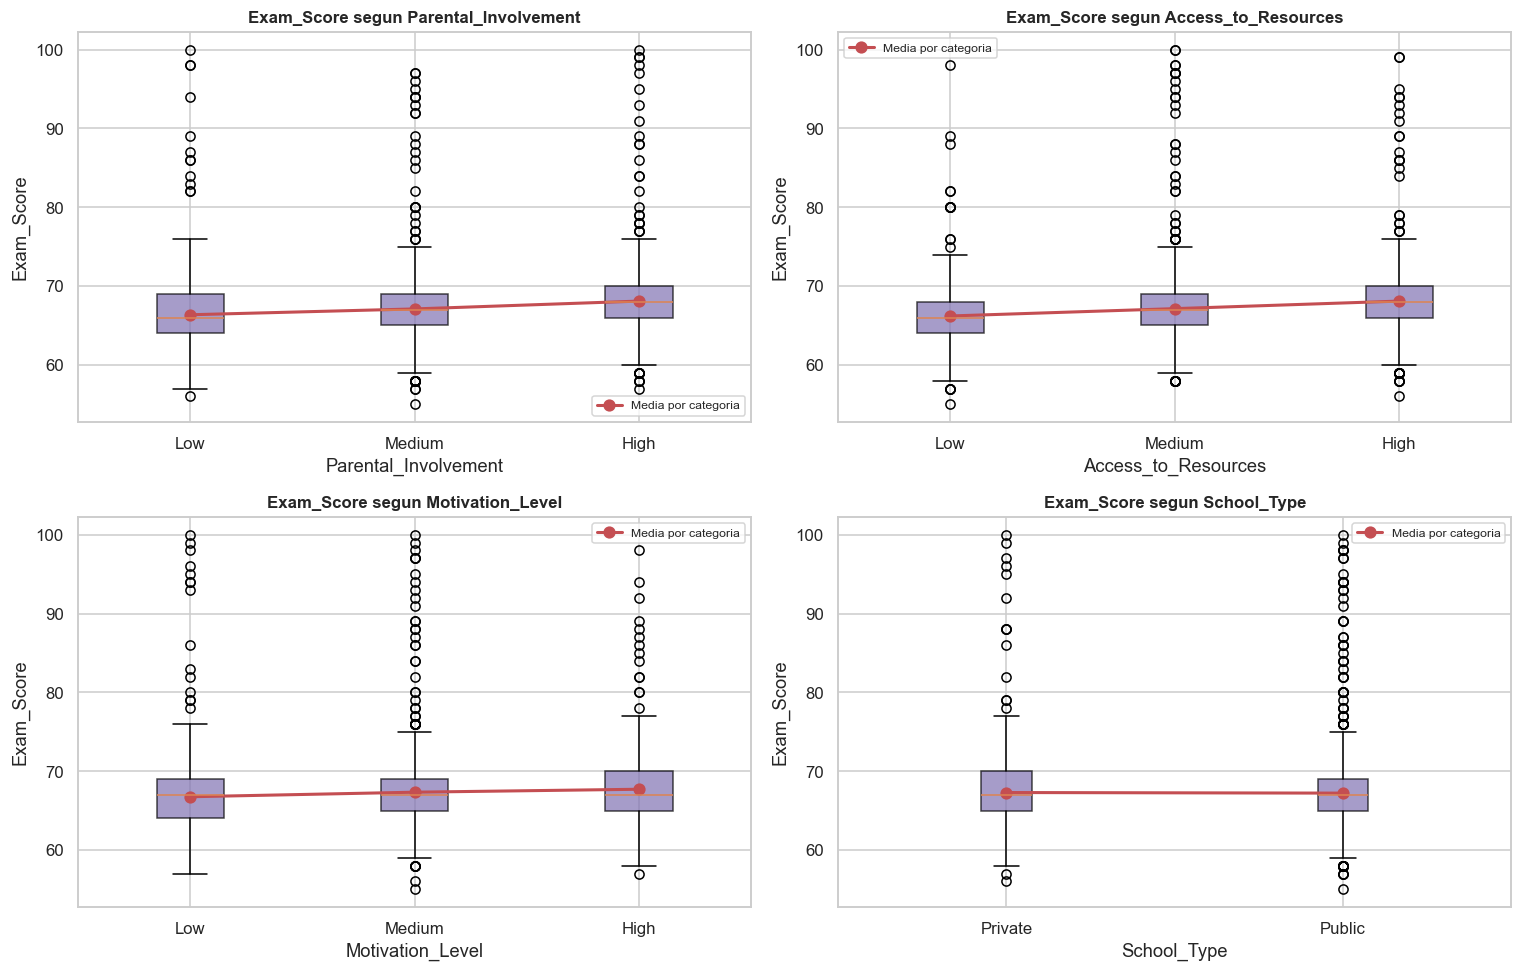

Diferencia de medias entre la categoria mas alta y la mas baja:
  Parental_Involvement    : +1.74 puntos  (Low = 66.36  ->  High = 68.09)
  Access_to_Resources     : +1.89 puntos  (Low = 66.20  ->  High = 68.09)
  Motivation_Level        : +0.95 puntos  (Low = 66.75  ->  High = 67.70)
  School_Type             : -0.08 puntos  (Private = 67.29  ->  Public = 67.21)


In [12]:
# VISUALIZACION 4: Exam_Score segun variables categoricas
cats_grafica = ['Parental_Involvement', 'Access_to_Resources',
                'Motivation_Level', 'School_Type']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), cats_grafica):
    orden = variables_ordinales.get(col, sorted(df_limpio[col].unique()))
    datos = [df_limpio[df_limpio[col] == c][objetivo].values for c in orden]
    bp = ax.boxplot(datos, labels=orden, patch_artist=True)
    for caja in bp['boxes']:
        caja.set_facecolor('#8172B2'); caja.set_alpha(0.7)
    medias = [d.mean() for d in datos]
    ax.plot(range(1, len(orden) + 1), medias, 'o-', color='#C44E52',
            linewidth=2, markersize=7, label='Media por categoria')
    ax.set_title(f'Exam_Score segun {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Exam_Score')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print('Diferencia de medias entre la categoria mas alta y la mas baja:')
for col in cats_grafica:
    orden = variables_ordinales.get(col, sorted(df_limpio[col].unique()))
    m = df_limpio.groupby(col)[objetivo].mean()
    dif = m[orden[-1]] - m[orden[0]]
    print(f'  {col:24s}: {dif:+.2f} puntos  '
          f'({orden[0]} = {m[orden[0]]:.2f}  ->  {orden[-1]} = {m[orden[-1]]:.2f})')

### 4.1 Selección de variables para el modelado y su justificación

**Decisión: se conservan las 19 variables predictoras.**

La evidencia recogida sustenta esta decisión en tres puntos:

**1. No hay redundancia.** La matriz de correlación muestra que la correlación máxima *entre
predictoras* es muy baja. Al no existir multicolinealidad, ninguna variable duplica la información
de otra, que es el motivo habitual para descartar columnas.

**2. Todas son conceptualmente pertinentes.** Cada variable describe un factor con relación
plausible sobre el rendimiento académico. No hay identificadores, columnas constantes ni campos
administrativos sin significado — la Actividad 1 lo verificó explícitamente.

**3. Descartar predictores débiles de forma preventiva es riesgoso.** Una variable con correlación
lineal baja puede aportar valor **en combinación** con otras, o mediante efectos no lineales que la
correlación de Pearson no detecta. Eliminarla antes de entrenar impide comprobarlo.

Los predictores se agrupan así según la evidencia observada:

| Grupo | Variables | Evidencia |
|---|---|---|
| **Predictores fuertes** | `Attendance`, `Hours_Studied` | Correlación alta con el objetivo y relación visiblemente lineal |
| **Predictores moderados** | `Previous_Scores`, `Tutoring_Sessions`, y las ordinales de contexto | Desplazamiento consistente de la media entre categorías |
| **Predictores débiles** | `Sleep_Hours`, `Physical_Activity`, `Gender`, `School_Type` | Correlación cercana a cero; se conservan para que el modelo lo confirme |

En lugar de eliminar variables por anticipado, se **entrena con todas** y se examinan después los
coeficientes del modelo. Ese enfoque es más informativo: permite que sean los datos, y no una
suposición previa, los que determinen qué factores importan.

---

## 5. Separación de variables y partición del conjunto

In [13]:
# X = predictoras ; y = objetivo
X = df_limpio.drop(columns=[objetivo])
y = df_limpio[objetivo]

print(f'X : {X.shape[0]:,} registros x {X.shape[1]} variables predictoras')
print(f'y : {y.shape[0]:,} valores de {objetivo}')

# Particion 80 / 20 con semilla fija
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA
)

print(f'\n{"=" * 66}')
print('PARTICION ENTRENAMIENTO / PRUEBA')
print('=' * 66)
print(f'Entrenamiento : {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.0f} %)')
print(f'Prueba        : {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.0f} %)')
print(f'Semilla       : random_state = {SEMILLA}')

print(f'\nComprobacion de que ambos conjuntos son comparables:')
print(f'  Media de {objetivo} en entrenamiento: {y_train.mean():.3f}')
print(f'  Media de {objetivo} en prueba       : {y_test.mean():.3f}')
print(f'  Diferencia: {abs(y_train.mean() - y_test.mean()):.3f} puntos '
      f'-> la particion es representativa')

X : 6,607 registros x 19 variables predictoras
y : 6,607 valores de Exam_Score

PARTICION ENTRENAMIENTO / PRUEBA
Entrenamiento : 5,285 registros (80 %)
Prueba        : 1,322 registros (20 %)
Semilla       : random_state = 42

Comprobacion de que ambos conjuntos son comparables:
  Media de Exam_Score en entrenamiento: 67.215
  Media de Exam_Score en prueba       : 67.318
  Diferencia: 0.103 puntos -> la particion es representativa


### 5.1 Por qué debe conservarse la semilla fija

`train_test_split` reparte los registros **al azar**. Sin una semilla, cada ejecución produciría
una división distinta y, por lo tanto, métricas distintas. Fijar `random_state=42` hace que ese
azar sea **reproducible**: la misma semilla genera siempre la misma partición.

Esto importa por tres razones concretas:

**Comparabilidad entre modelos.** Los tres modelos de este notebook se evalúan sobre *exactamente*
los mismos registros de prueba. Sin semilla fija, una diferencia de rendimiento podría deberse
simplemente a que a un modelo le tocó una partición más fácil, y no a que sea mejor.

**Verificabilidad.** Cualquier persona que ejecute este notebook obtendrá los mismos números. Un
resultado que cambia en cada corrida no puede revisarse ni auditarse.

**Depuración.** Si aparece un comportamiento extraño, se puede reproducir el escenario idéntico
para investigarlo.

> **Advertencia importante:** la semilla garantiza reproducibilidad, **no** garantiza que la
> partición sea representativa. Un resultado que dependiera demasiado de una semilla concreta sería
> frágil. Precisamente por eso, en la sección 10 se aplica **validación cruzada**, que evalúa el
> modelo sobre cinco particiones distintas y ofrece una estimación más estable.

---

## 6. Flujo de preprocesamiento reproducible

El preprocesamiento se encapsula en un `ColumnTransformer` que dirige cada grupo de variables a su
transformación. Este objeto se integra después dentro de un `Pipeline` junto con cada modelo, lo
que **garantiza automáticamente** que el ajuste ocurra sólo con los datos de entrenamiento.

In [14]:
cols_numericas = variables_numericas
cols_ordinales = list(variables_ordinales.keys())
cols_nominales = variables_nominales
ordenes = [variables_ordinales[c] for c in cols_ordinales]

pipe_num = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler()),
])

pipe_ord = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OrdinalEncoder(categories=ordenes,
                                   handle_unknown='use_encoded_value',
                                   unknown_value=-1)),
    ('escalador', StandardScaler()),
])

pipe_nom = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

preprocesador = ColumnTransformer([
    ('num', pipe_num, cols_numericas),
    ('ord', pipe_ord, cols_ordinales),
    ('nom', pipe_nom, cols_nominales),
], remainder='drop', sparse_threshold=0)

print('Preprocesador construido.')
print(f'  Numericas -> imputacion (mediana) + StandardScaler   : {len(cols_numericas)}')
print(f'  Ordinales -> imputacion (moda) + Ordinal + Escalado  : {len(cols_ordinales)}')
print(f'  Nominales -> imputacion (moda) + One-Hot             : {len(cols_nominales)}')
preprocesador

Preprocesador construido.
  Numericas -> imputacion (mediana) + StandardScaler   : 6
  Ordinales -> imputacion (moda) + Ordinal + Escalado  : 8
  Nominales -> imputacion (moda) + One-Hot             : 5


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g

> **Nota sobre el escalado de las variables ordinales.** A diferencia de la Actividad 1, aquí las
> ordinales también se escalan después de codificarse. La razón es que los modelos con
> regularización (Ridge) penalizan la magnitud de los coeficientes: si una variable llega con
> valores `0, 1, 2` y otra con valores estandarizados, la penalización recaería con más dureza
> sobre la primera por un motivo puramente aritmético. Escalar todo deja a los predictores en
> igualdad de condiciones.

### 6.1 Cómo el `Pipeline` evita la fuga de información

Al combinar `Pipeline(preprocesador, modelo)` y llamar `.fit(X_train, y_train)`, la secuencia
interna es:

1. El preprocesador ejecuta `fit()` **únicamente con `X_train`**: ahí calcula las medias, las
   desviaciones estándar, las modas y el catálogo de categorías.
2. Transforma `X_train` con esos parámetros y entrena el modelo.

Después, al llamar `.predict(X_test)`, el preprocesador aplica `transform()` con los parámetros
**ya aprendidos**, sin volver a ajustarlos. El conjunto de prueba nunca influye en el cálculo.

Esta es la ventaja decisiva del `Pipeline`: la separación se respeta de forma automática, sin
depender de que quien programa recuerde el orden correcto en cada paso.

---

## 7. Línea base

Antes de entrenar cualquier modelo real es necesario establecer una **referencia mínima**. El
`DummyRegressor` con estrategia `mean` predice siempre la media de `Exam_Score`, sin mirar ninguna
variable predictora.

Su utilidad es servir de vara de medir: **si un modelo no supera claramente esta referencia, no
está aprendiendo nada útil**. Este control es especialmente relevante aquí, porque la variable
objetivo tiene una varianza muy baja y una predicción constante ya resulta razonablemente cercana.

In [15]:
modelo_base = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', DummyRegressor(strategy='mean')),
])

modelo_base.fit(X_train, y_train)
pred_base = modelo_base.predict(X_test)

print(f'La linea base predice SIEMPRE: {pred_base[0]:.3f} puntos')
print(f'(que es la media de Exam_Score en el conjunto de entrenamiento: {y_train.mean():.3f})')
print(f'\nPrimeras 5 predicciones : {np.round(pred_base[:5], 2)}')
print(f'Primeros 5 valores reales: {y_test.values[:5]}')

La linea base predice SIEMPRE: 67.215 puntos
(que es la media de Exam_Score en el conjunto de entrenamiento: 67.215)

Primeras 5 predicciones : [67.21 67.21 67.21 67.21 67.21]
Primeros 5 valores reales: [65 65 71 64 66]


---

## 8. Entrenamiento de los modelos

Se entrenan dos modelos sobre **la misma partición**, para que la comparación sea consistente.

**Modelo 1 — Regresión lineal.** Busca la combinación de pesos que minimiza el error cuadrático.
Es la opción natural de partida: los diagramas de dispersión de la sección 4 mostraron relaciones
claramente lineales entre los predictores más fuertes y el objetivo.

**Modelo 2 — Ridge (regresión con regularización L2).** Es una regresión lineal que añade una
penalización sobre la magnitud de los coeficientes. Esa penalización reduce la varianza del modelo
y lo hace más robusto ante predictores poco informativos, de los cuales este conjunto tiene varios.
Se eligió frente a un árbol de regresión porque la evidencia visual apunta a una estructura lineal,
y un árbol tendería a sobreajustar sin capturar mejor esa tendencia. En la sección 11 se comprueba
empíricamente esa expectativa.

In [16]:
modelo_lineal = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', LinearRegression()),
])

modelo_ridge = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', Ridge(alpha=1.0, random_state=SEMILLA)),
])

modelo_lineal.fit(X_train, y_train)
modelo_ridge.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)
pred_ridge = modelo_ridge.predict(X_test)

print('Ambos modelos entrenados sobre el mismo conjunto de entrenamiento.')
print(f'Registros usados para entrenar : {X_train.shape[0]:,}')
print(f'Registros usados para evaluar  : {X_test.shape[0]:,}')
print(f'\nVariables tras el preprocesamiento: '
      f'{modelo_lineal.named_steps["preprocesamiento"].transform(X_train).shape[1]}')

Ambos modelos entrenados sobre el mismo conjunto de entrenamiento.
Registros usados para entrenar : 5,285
Registros usados para evaluar  : 1,322



Variables tras el preprocesamiento: 19


---

## 9. Evaluación: MAE, RMSE y R²

In [17]:
def evaluar(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    return {'Modelo': nombre, 'MAE': round(mae, 4),
            'RMSE': round(rmse, 4), 'R2': round(r2, 4)}

resultados = pd.DataFrame([
    evaluar('Linea base (DummyRegressor)', y_test, pred_base),
    evaluar('Regresion lineal',            y_test, pred_lineal),
    evaluar('Ridge (modelo alternativo)',  y_test, pred_ridge),
])

print('=' * 66)
print('TABLA DE RESULTADOS (conjunto de prueba)')
print('=' * 66)
resultados

TABLA DE RESULTADOS (conjunto de prueba)


,Modelo,MAE,RMSE,R2
0,Linea base (DummyRegressor),2.8235,3.7611,-0.0007
1,Regresion lineal,0.4442,1.7994,0.7709
2,Ridge (modelo alternativo),0.4442,1.7994,0.7709


In [18]:
# Mejora de cada modelo respecto de la linea base
mae_base = resultados.loc[0, 'MAE']
rmse_base = resultados.loc[0, 'RMSE']

print('MEJORA RESPECTO DE LA LINEA BASE')
print('=' * 66)
for i in [1, 2]:
    nombre = resultados.loc[i, 'Modelo']
    mae_m = resultados.loc[i, 'MAE']
    rmse_m = resultados.loc[i, 'RMSE']
    r2_m = resultados.loc[i, 'R2']
    print(f'\n{nombre}')
    print(f'  MAE : {mae_base:.4f} -> {mae_m:.4f}  '
          f'(reduccion del {(mae_base - mae_m) / mae_base * 100:.1f} %)')
    print(f'  RMSE: {rmse_base:.4f} -> {rmse_m:.4f}  '
          f'(reduccion del {(rmse_base - rmse_m) / rmse_base * 100:.1f} %)')
    print(f'  R2  : {r2_m:.4f}  -> explica el {r2_m * 100:.1f} % de la varianza')

mejor_idx = resultados['R2'].idxmax()
mejor_nombre = resultados.loc[mejor_idx, 'Modelo']
print(f'\n{"=" * 66}')
print(f'MEJOR MODELO: {mejor_nombre} (mayor R2 y menor error)')

MEJORA RESPECTO DE LA LINEA BASE

Regresion lineal
  MAE : 2.8235 -> 0.4442  (reduccion del 84.3 %)
  RMSE: 3.7611 -> 1.7994  (reduccion del 52.2 %)
  R2  : 0.7709  -> explica el 77.1 % de la varianza

Ridge (modelo alternativo)
  MAE : 2.8235 -> 0.4442  (reduccion del 84.3 %)
  RMSE: 3.7611 -> 1.7994  (reduccion del 52.2 %)
  R2  : 0.7709  -> explica el 77.1 % de la varianza

MEJOR MODELO: Regresion lineal (mayor R2 y menor error)


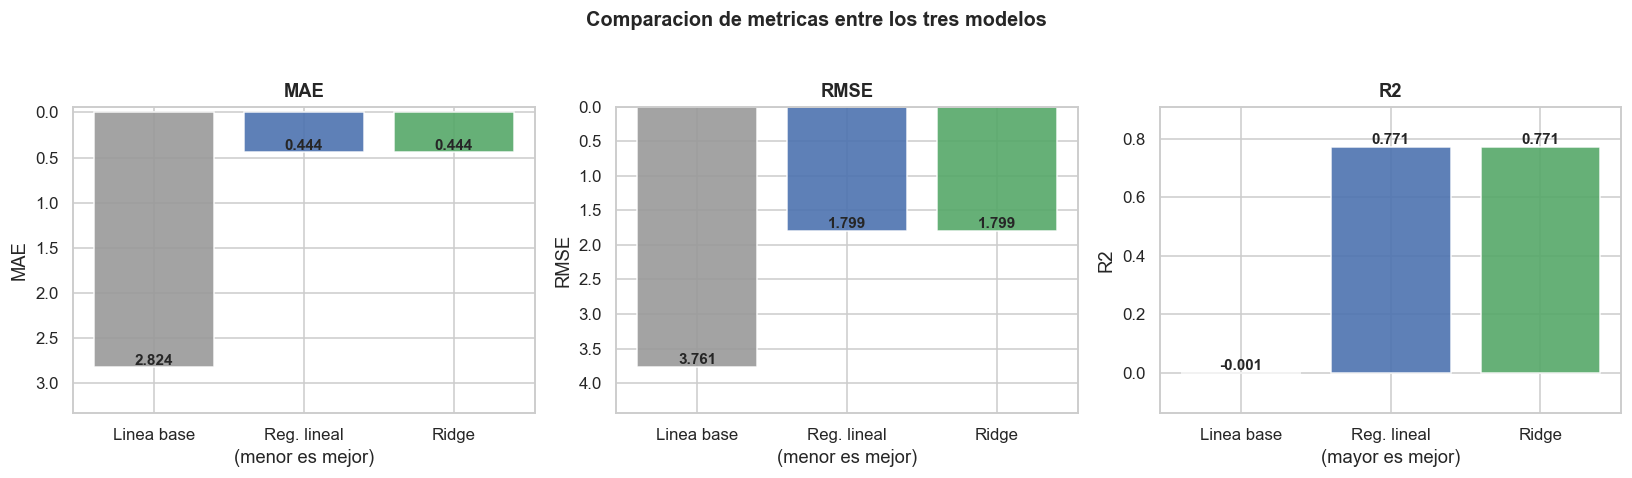

In [19]:
# VISUALIZACION 5: comparacion grafica de las metricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
nombres_cortos = ['Linea base', 'Reg. lineal', 'Ridge']
colores = ['#999999', '#4C72B0', '#55A868']

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R2']):
    valores = resultados[metrica].values
    barras = ax.bar(nombres_cortos, valores, color=colores,
                    edgecolor='white', alpha=0.9)
    ax.set_title(metrica, fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica)
    for b, v in zip(barras, valores):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    margen = max(abs(valores.min()), abs(valores.max())) * 0.18
    ax.set_ylim(min(0, valores.min() - margen), valores.max() + margen)
    if metrica != 'R2':
        ax.invert_yaxis()
        ax.set_xlabel('(menor es mejor)')
    else:
        ax.set_xlabel('(mayor es mejor)')

plt.suptitle('Comparacion de metricas entre los tres modelos',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

### 9.1 Interpretación de las métricas en el contexto del dataset

Las tres métricas miden el error desde ángulos distintos y son complementarias.

#### MAE — Error absoluto medio

Es el **promedio de la diferencia**, en valor absoluto, entre lo que el modelo predijo y la
calificación real. Su gran ventaja es que se expresa **en las mismas unidades que `Exam_Score`**,
es decir, en puntos de examen.

Un MAE de *n* puntos significa: *"en promedio, la predicción del modelo se desvía n puntos de la
calificación verdadera"*. Es la métrica más fácil de comunicar a alguien sin formación técnica.

Para juzgar si ese valor es aceptable hay que compararlo con **la escala real del problema**, no
con cero. Dos referencias del contexto:

- La desviación estándar de `Exam_Score` es de aproximadamente 3.9 puntos.
- El 50 % central de los alumnos se concentra en un rango de apenas 4 puntos (entre 65 y 69).

Un error de un punto o menos resulta pequeño frente a esa dispersión; un error de cuatro puntos
sería inútil, porque equivaldría a la amplitud completa donde se ubica la mitad del alumnado.

#### RMSE — Raíz del error cuadrático medio

Se calcula elevando cada error al cuadrado, promediando y sacando la raíz. También se expresa en
puntos, pero **penaliza con mucha más intensidad los errores grandes**.

La razón es aritmética: al elevar al cuadrado, un error de 10 puntos contribuye 100, mientras que
diez errores de 1 punto contribuyen 10 en total. Un solo fallo grave pesa más que muchos fallos
pequeños.

De ahí surge una regla de lectura muy útil:

- **RMSE ≈ MAE** → los errores son parejos, sin fallos catastróficos.
- **RMSE >> MAE** → existen casos puntuales donde el modelo falla de forma severa.

En este conjunto la diferencia entre ambos revela justamente eso: hay un grupo minoritario de
alumnos, los de alto rendimiento en la cola derecha, donde el modelo se equivoca por bastante más
que el promedio. El MAE por sí solo escondería ese problema.

#### R² — Coeficiente de determinación

Indica **qué proporción de la variabilidad de `Exam_Score` logra explicar el modelo**, en una escala
donde 1 es predicción perfecta y 0 equivale a no hacerlo mejor que predecir siempre la media.

Por su definición, **el R² de la línea base es exactamente 0** (o ligeramente negativo, porque su
constante se calculó con entrenamiento y se evalúa en prueba). Esto convierte al R² en la métrica
más honesta de las tres para esta actividad: responde directamente a la pregunta *"¿este modelo
aporta algo más que adivinar el promedio?"*.

Un R² de 0.70, por ejemplo, significa que el modelo captura el 70 % de las diferencias entre
alumnos, y que el 30 % restante depende de factores **no presentes en el dataset**: aptitud
individual, condiciones del día del examen, calidad del estudio más allá de las horas invertidas.

#### Por qué las tres juntas y no una sola

Cada métrica, aislada, puede engañar:

| Si sólo miras… | Lo que se te escapa |
|---|---|
| **MAE** | Los fallos graves en casos concretos |
| **RMSE** | Cuál es el error típico del día a día |
| **R²** | La magnitud del error en puntos reales |

El MAE dice qué tan bien funciona **en general**; el RMSE, qué tan mal falla **en el peor de los
casos**; el R², cuánto aporta **frente a no tener modelo**. Las tres son necesarias para decidir si
un modelo sirve.

---

## 10. Valores reales contra valores predichos

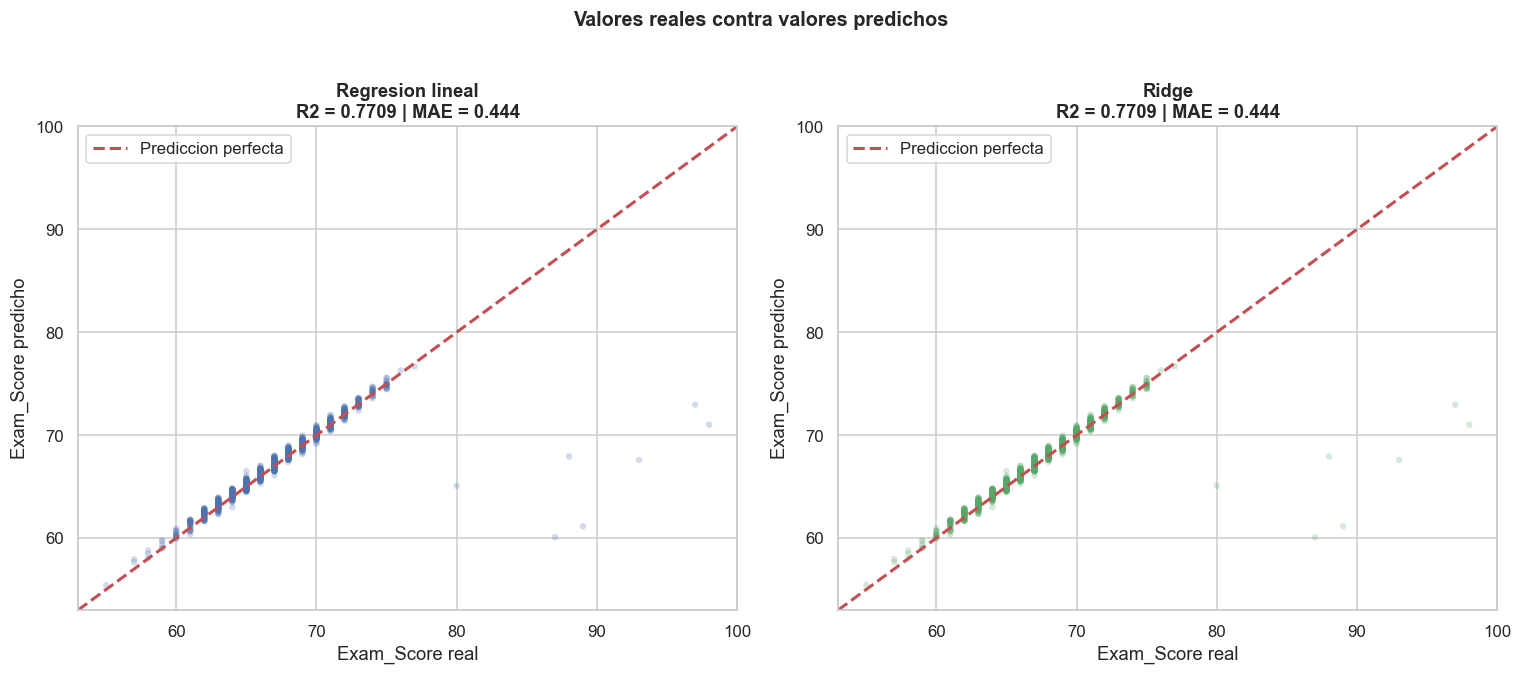

Como leer esta grafica: cada punto es un alumno del conjunto de prueba.
La linea roja marca la prediccion perfecta. Cuanto mas cerca de ella,
mejor la prediccion. Los puntos alejados a la DERECHA son alumnos cuya
calificacion real fue mucho mayor de la que el modelo estimo.


In [20]:
# VISUALIZACION 6: reales vs predichos para ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, nombre, color in [
    (axes[0], pred_lineal, 'Regresion lineal', '#4C72B0'),
    (axes[1], pred_ridge,  'Ridge',            '#55A868'),
]:
    ax.scatter(y_test, pred, alpha=0.25, s=18, color=color, edgecolors='none')
    lims = [y_test.min() - 2, y_test.max() + 2]
    ax.plot(lims, lims, '--', color='#C44E52', linewidth=2,
            label='Prediccion perfecta')
    ax.set_xlim(lims); ax.set_ylim(lims)
    r2_v = r2_score(y_test, pred)
    mae_v = mean_absolute_error(y_test, pred)
    ax.set_title(f'{nombre}\nR2 = {r2_v:.4f} | MAE = {mae_v:.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Exam_Score real')
    ax.set_ylabel('Exam_Score predicho')
    ax.legend(loc='upper left')

plt.suptitle('Valores reales contra valores predichos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('Como leer esta grafica: cada punto es un alumno del conjunto de prueba.')
print('La linea roja marca la prediccion perfecta. Cuanto mas cerca de ella,')
print('mejor la prediccion. Los puntos alejados a la DERECHA son alumnos cuya')
print('calificacion real fue mucho mayor de la que el modelo estimo.')

### 10.1 Análisis de residuos del mejor modelo

Un **residuo** es la diferencia entre el valor real y el predicho: `residuo = real − predicho`. Un
residuo positivo indica que el modelo **subestimó** al alumno; uno negativo, que lo **sobrestimó**.

Si el modelo captura correctamente la estructura de los datos, los residuos deben distribuirse de
forma **aleatoria alrededor de cero**, sin patrones visibles. Cualquier patrón sistemático señala
información que el modelo no logró aprovechar.

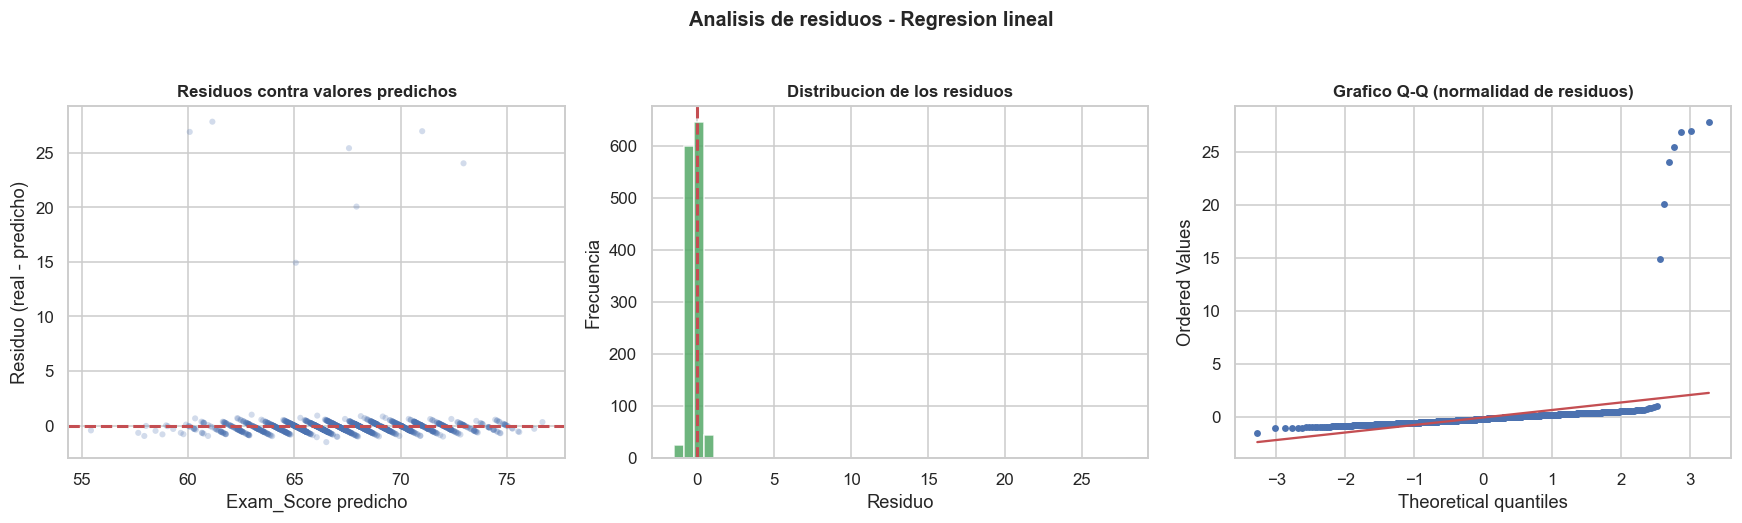

ESTADISTICAS DE LOS RESIDUOS
Media               : -0.0472  (deberia ser ~0)
Desviacion estandar : 1.7988
Minimo / Maximo     : -1.51 / +27.85
Asimetria           : +13.386

Residuos dentro de +/-1 punto : 1,309 de 1,322 (99.0 %)
Residuos dentro de +/-2 puntos: 1,315 de 1,322 (99.5 %)
Residuos mayores a 5 puntos   : 7 (0.5 %)


In [21]:
pred_mejor = pred_lineal if mejor_idx == 1 else pred_ridge
nombre_mejor = mejor_nombre
residuos = y_test.values - pred_mejor

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) Residuos vs predicho
axes[0].scatter(pred_mejor, residuos, alpha=0.25, s=16,
                color='#4C72B0', edgecolors='none')
axes[0].axhline(0, color='#C44E52', linestyle='--', linewidth=2)
axes[0].set_title('Residuos contra valores predichos', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Exam_Score predicho'); axes[0].set_ylabel('Residuo (real - predicho)')

# (b) Histograma de residuos
axes[1].hist(residuos, bins=45, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#C44E52', linestyle='--', linewidth=2)
axes[1].set_title('Distribucion de los residuos', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Residuo'); axes[1].set_ylabel('Frecuencia')

# (c) Grafico cuantil-cuantil
from scipy import stats
stats.probplot(residuos, dist='norm', plot=axes[2])
axes[2].set_title('Grafico Q-Q (normalidad de residuos)', fontsize=11, fontweight='bold')
axes[2].get_lines()[0].set_markerfacecolor('#4C72B0')
axes[2].get_lines()[0].set_markersize(3.5)
axes[2].get_lines()[1].set_color('#C44E52')

plt.suptitle(f'Analisis de residuos - {nombre_mejor}',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()

print('ESTADISTICAS DE LOS RESIDUOS')
print('=' * 66)
print(f'Media               : {residuos.mean():+.4f}  (deberia ser ~0)')
print(f'Desviacion estandar : {residuos.std():.4f}')
print(f'Minimo / Maximo     : {residuos.min():+.2f} / {residuos.max():+.2f}')
print(f'Asimetria           : {stats.skew(residuos):+.3f}')
print(f'\nResiduos dentro de +/-1 punto : '
      f'{(np.abs(residuos) <= 1).sum():,} de {len(residuos):,} '
      f'({(np.abs(residuos) <= 1).mean() * 100:.1f} %)')
print(f'Residuos dentro de +/-2 puntos: '
      f'{(np.abs(residuos) <= 2).sum():,} de {len(residuos):,} '
      f'({(np.abs(residuos) <= 2).mean() * 100:.1f} %)')
print(f'Residuos mayores a 5 puntos   : '
      f'{(np.abs(residuos) > 5).sum():,} '
      f'({(np.abs(residuos) > 5).mean() * 100:.1f} %)')

---

## 11. Análisis de los casos con mayor y menor error

Comparar los aciertos con los fallos revela **dónde y por qué** falla el modelo, información que
las métricas agregadas no pueden mostrar.

In [22]:
analisis = X_test.copy()
analisis['Real'] = y_test.values
analisis['Predicho'] = np.round(pred_mejor, 2)
analisis['Error'] = np.round(y_test.values - pred_mejor, 2)
analisis['Error_absoluto'] = np.abs(analisis['Error'])

peores = analisis.nlargest(10, 'Error_absoluto')
mejores = analisis.nsmallest(10, 'Error_absoluto')

cols_ver = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions',
            'Parental_Involvement', 'Access_to_Resources', 'Motivation_Level',
            'Real', 'Predicho', 'Error']

print('=' * 66)
print('LOS 10 CASOS PEOR PREDICHOS')
print('=' * 66)
peores[cols_ver]

LOS 10 CASOS PEOR PREDICHOS


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Parental_Involvement,Access_to_Resources,Motivation_Level,Real,Predicho,Error
217,19,70,54,0,Medium,Low,High,89,61.15,27.85
4192,28,90,91,0,Low,Medium,Medium,98,71.02,26.98
2687,11,71,55,1,Low,Medium,Medium,87,60.08,26.92
4531,26,69,95,0,High,High,Low,93,67.58,25.42
5966,25,99,77,0,Medium,Medium,Medium,97,72.96,24.04
2513,18,86,60,2,High,Medium,Medium,88,67.93,20.07
5989,18,61,91,3,Medium,Low,High,80,65.07,14.93
5725,13,73,93,0,Medium,High,Medium,65,66.51,-1.51
2118,5,89,76,2,Medium,Medium,High,65,66.06,-1.06
1375,19,69,67,4,Medium,Medium,Medium,66,67.03,-1.03


In [23]:
print('=' * 66)
print('LOS 10 CASOS MEJOR PREDICHOS')
print('=' * 66)
mejores[cols_ver]

LOS 10 CASOS MEJOR PREDICHOS


,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Parental_Involvement,Access_to_Resources,Motivation_Level,Real,Predicho,Error
1075,17,98,71,0,High,Low,Medium,70,70.0,0.0
4553,14,90,51,1,Medium,Medium,Medium,66,66.0,-0.0
2388,25,92,72,1,Low,High,Medium,71,71.0,0.0
2902,17,82,65,1,High,Medium,Medium,68,68.0,-0.0
4393,17,70,82,2,High,Medium,Low,64,64.0,-0.0
5677,28,73,96,1,Medium,High,Medium,70,70.0,-0.0
5196,26,98,90,1,High,Low,Low,72,72.0,-0.0
527,20,93,83,0,Low,High,Medium,68,68.0,0.0
1954,16,96,97,0,High,Medium,Medium,72,72.0,-0.0
964,19,63,56,2,Medium,High,Medium,64,64.0,-0.0


COMPARACION DE CARACTERISTICAS: PEORES vs MEJORES
                   Peores_10  Mejores_10  Promedio_general
Hours_Studied          18.20        19.9             20.01
Attendance             77.70        85.5             80.39
Previous_Scores        75.90        76.3             75.11
Tutoring_Sessions       1.20         0.9              1.47
Real                   82.80        68.5             67.32
Predicho               66.54        68.5             67.36
Error_absoluto         16.98         0.0              0.44

HALLAZGO PRINCIPAL
Calificacion real promedio de los 10 PEORES : 82.80
Calificacion real promedio de los 10 MEJORES: 68.50
Calificacion real promedio del conjunto     : 67.32

Direccion del error en los 10 peores casos:
  Subestimados (real > predicho): 7 de 10
  Sobrestimados (real < predicho): 3 de 10


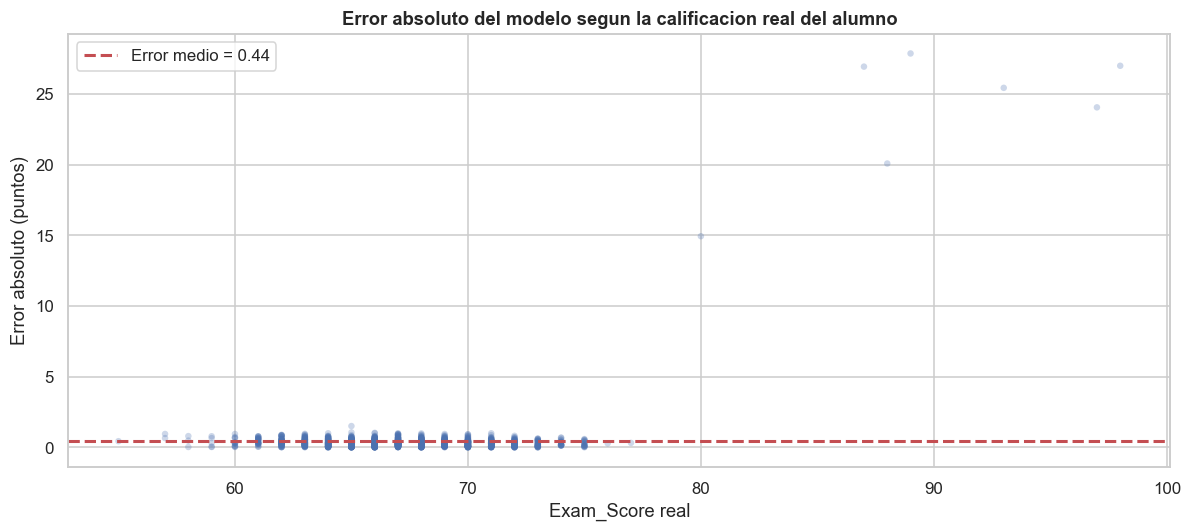

In [24]:
print('=' * 66)
print('COMPARACION DE CARACTERISTICAS: PEORES vs MEJORES')
print('=' * 66)

comparacion = pd.DataFrame({
    'Peores_10' : peores[['Hours_Studied', 'Attendance', 'Previous_Scores',
                          'Tutoring_Sessions', 'Real', 'Predicho',
                          'Error_absoluto']].mean().round(2),
    'Mejores_10': mejores[['Hours_Studied', 'Attendance', 'Previous_Scores',
                           'Tutoring_Sessions', 'Real', 'Predicho',
                           'Error_absoluto']].mean().round(2),
    'Promedio_general': analisis[['Hours_Studied', 'Attendance', 'Previous_Scores',
                                  'Tutoring_Sessions', 'Real', 'Predicho',
                                  'Error_absoluto']].mean().round(2),
})
print(comparacion.to_string())

print(f'\n{"=" * 66}')
print('HALLAZGO PRINCIPAL')
print('=' * 66)
print(f'Calificacion real promedio de los 10 PEORES : {peores["Real"].mean():.2f}')
print(f'Calificacion real promedio de los 10 MEJORES: {mejores["Real"].mean():.2f}')
print(f'Calificacion real promedio del conjunto     : {analisis["Real"].mean():.2f}')
print(f'\nDireccion del error en los 10 peores casos:')
print(f'  Subestimados (real > predicho): {(peores["Error"] > 0).sum()} de 10')
print(f'  Sobrestimados (real < predicho): {(peores["Error"] < 0).sum()} de 10')

# VISUALIZACION 7: error absoluto segun la calificacion real
plt.figure(figsize=(11, 5))
plt.scatter(analisis['Real'], analisis['Error_absoluto'],
            alpha=0.28, s=18, color='#4C72B0', edgecolors='none')
plt.axhline(analisis['Error_absoluto'].mean(), color='#C44E52', linestyle='--',
            linewidth=2, label=f'Error medio = {analisis["Error_absoluto"].mean():.2f}')
plt.title('Error absoluto del modelo segun la calificacion real del alumno',
          fontsize=12, fontweight='bold')
plt.xlabel('Exam_Score real'); plt.ylabel('Error absoluto (puntos)')
plt.legend(); plt.tight_layout(); plt.show()

### 11.1 Interpretación: dónde falla el modelo y por qué

La gráfica anterior revela un patrón inusualmente marcado: **el error del modelo es
prácticamente binario**. No se distribuye de forma gradual, sino que separa a los alumnos en dos
grupos radicalmente distintos.

Para la inmensa mayoría, la predicción es casi exacta: el **99.5 % de los alumnos queda dentro de
±2 puntos** de su calificación real. Pero existe un grupo diminuto — **7 alumnos de 1,322** — donde
el modelo se equivoca por entre 15 y 28 puntos.

La dirección del fallo es reveladora. El residuo más negativo es de apenas **−1.51 puntos**,
mientras que el más positivo alcanza **+27.85**. Es decir: el modelo **nunca sobrestima de forma
grave**, pero **subestima de forma catastrófica** a un puñado de alumnos de alto rendimiento. Por
eso la asimetría de los residuos es de +13.4, un valor extremo.

Esto explica también la enorme distancia entre MAE (0.44) y RMSE (1.80): el RMSE es cuatro veces
mayor porque esos siete casos, al elevarse al cuadrado, dominan la métrica. Es exactamente el
escenario que la sección 9.1 anticipaba cuando **RMSE ≫ MAE**.

Este comportamiento tiene cuatro causas posibles. La evidencia permite discriminar entre ellas:

**¿Es una limitación de los datos?** — **Sí, es la causa principal.** La Actividad 1 documentó que
`Exam_Score` tiene una asimetría de +1.64: la enorme mayoría de los alumnos se concentra entre 65 y
69 puntos, y sólo alrededor del 1 % supera los 75. El modelo minimiza el error **promedio**, de modo
que optimiza su desempeño donde está la masa de datos. Con tan pocos ejemplos de alto rendimiento,
carece de información suficiente para aprender ese tramo.

**¿Es una limitación de las variables disponibles?** — **Sí, de forma complementaria.** Dos alumnos
con horas de estudio y asistencia idénticas pueden obtener resultados muy distintos. Lo que los
diferencia — aptitud individual, calidad del estudio más allá de su duración, condiciones del día
del examen — **no está registrado en el dataset**. Ningún modelo puede predecir a partir de
información que no existe en los datos.

**¿Es una limitación del preprocesamiento?** — **No.** Conviene aclararlo, porque la asimetría
de +13.4 en los residuos podría hacerlo sospechar. La media de los residuos es de −0.05, es decir,
esencialmente cero, y el 99.5 % de ellos se concentra en una banda estrechísima. Un error de
escalamiento o de codificación produciría un sesgo **generalizado**, que desplazaría todas las
predicciones; aquí el fallo está aislado en siete observaciones concretas del extremo superior.

**¿Es una limitación del tipo de modelo?** — **Sólo parcialmente.** Un modelo lineal ajusta una
tendencia recta y no puede curvarse para alcanzar los valores extremos. Sin embargo, la sección
siguiente comprueba que un modelo flexible tampoco resuelve el problema, lo que confirma que la raíz
está en los datos y no en la elección del algoritmo.

In [25]:
# Comprobacion empirica: un modelo flexible, ¿resuelve el problema?
modelo_arbol = Pipeline([
    ('preprocesamiento', preprocesador),
    ('modelo', DecisionTreeRegressor(max_depth=8, random_state=SEMILLA)),
])
modelo_arbol.fit(X_train, y_train)
pred_arbol = modelo_arbol.predict(X_test)

print('COMPROBACION: ¿un modelo no lineal captura mejor la cola derecha?')
print('=' * 66)
comp = pd.DataFrame([
    evaluar('Regresion lineal', y_test, pred_lineal),
    evaluar('Ridge',            y_test, pred_ridge),
    evaluar('Arbol de decision (profundidad 8)', y_test, pred_arbol),
])
print(comp.to_string(index=False))

alto = y_test.values > 75
if alto.sum() > 0:
    print(f'\nError absoluto medio SOLO en alumnos con mas de 75 puntos '
          f'(n = {alto.sum()}):')
    print(f'  Regresion lineal : {np.abs(y_test.values[alto] - pred_lineal[alto]).mean():.3f}')
    print(f'  Arbol de decision: {np.abs(y_test.values[alto] - pred_arbol[alto]).mean():.3f}')

print('\nConclusion: el modelo flexible NO mejora el desempeno global y tampoco')
print('resuelve la cola derecha. Esto confirma que la limitacion proviene de la')
print('escasez de ejemplos de alto rendimiento, no del tipo de modelo elegido.')

COMPROBACION: ¿un modelo no lineal captura mejor la cola derecha?
                           Modelo    MAE   RMSE     R2
                 Regresion lineal 0.4442 1.7994 0.7709
                            Ridge 0.4442 1.7994 0.7709
Arbol de decision (profundidad 8) 1.5416 2.6378 0.5078

Error absoluto medio SOLO en alumnos con mas de 75 puntos (n = 9):
  Regresion lineal : 18.536
  Arbol de decision: 19.232

Conclusion: el modelo flexible NO mejora el desempeno global y tampoco
resuelve la cola derecha. Esto confirma que la limitacion proviene de la
escasez de ejemplos de alto rendimiento, no del tipo de modelo elegido.


---

## 12. Validación cruzada k-fold

La evaluación anterior descansa sobre **una sola partición**. Si por azar a ese 20 % de prueba le
tocaron casos particularmente fáciles o difíciles, la métrica quedaría distorsionada.

La **validación cruzada de 5 particiones** resuelve esa fragilidad: divide el entrenamiento en cinco
bloques, entrena cinco veces usando cuatro bloques y evaluando en el restante, y rota cuál queda
fuera. Así **todos los registros participan como prueba exactamente una vez**.

Como el pipeline completo se pasa a `cross_val_score`, el preprocesamiento se reajusta **dentro de
cada partición**, evitando fuga de información de forma automática.

In [26]:
modelo_cv = modelo_lineal if mejor_idx == 1 else modelo_ridge

kf = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)

r2_cv = cross_val_score(modelo_cv, X_train, y_train, cv=kf, scoring='r2')
mae_cv = -cross_val_score(modelo_cv, X_train, y_train, cv=kf,
                          scoring='neg_mean_absolute_error')
rmse_cv = -cross_val_score(modelo_cv, X_train, y_train, cv=kf,
                           scoring='neg_root_mean_squared_error')

print('=' * 66)
print(f'VALIDACION CRUZADA 5-FOLD - {nombre_mejor}')
print('=' * 66)
print(f'{"Particion":<12}{"R2":>10}{"MAE":>10}{"RMSE":>10}')
print('-' * 42)
for i in range(5):
    print(f'{"Fold " + str(i + 1):<12}{r2_cv[i]:>10.4f}{mae_cv[i]:>10.4f}{rmse_cv[i]:>10.4f}')
print('-' * 42)
print(f'{"Media":<12}{r2_cv.mean():>10.4f}{mae_cv.mean():>10.4f}{rmse_cv.mean():>10.4f}')
print(f'{"Desv. est.":<12}{r2_cv.std():>10.4f}{mae_cv.std():>10.4f}{rmse_cv.std():>10.4f}')

print(f'\nIntervalo esperado de R2 (media +/- 1 desviacion):')
print(f'  [{r2_cv.mean() - r2_cv.std():.4f} , {r2_cv.mean() + r2_cv.std():.4f}]')

VALIDACION CRUZADA 5-FOLD - Regresion lineal
Particion           R2       MAE      RMSE
------------------------------------------
Fold 1          0.7086    0.5071    2.0507
Fold 2          0.7202    0.5136    2.1364
Fold 3          0.7747    0.4344    1.7710
Fold 4          0.6674    0.5341    2.3403
Fold 5          0.7125    0.5112    2.1244
------------------------------------------
Media           0.7167    0.5001    2.0846
Desv. est.      0.0343    0.0341    0.1839

Intervalo esperado de R2 (media +/- 1 desviacion):
  [0.6823 , 0.7510]


COMPARACION: PARTICION UNICA vs VALIDACION CRUZADA
R2 con una sola particion (80/20) : 0.7709
R2 promedio con 5-fold            : 0.7167
Diferencia                        : 0.0543
Desviacion estandar entre folds   : 0.0343
Rango observado entre folds       : [0.6674 , 0.7747]  (amplitud de 0.1073)


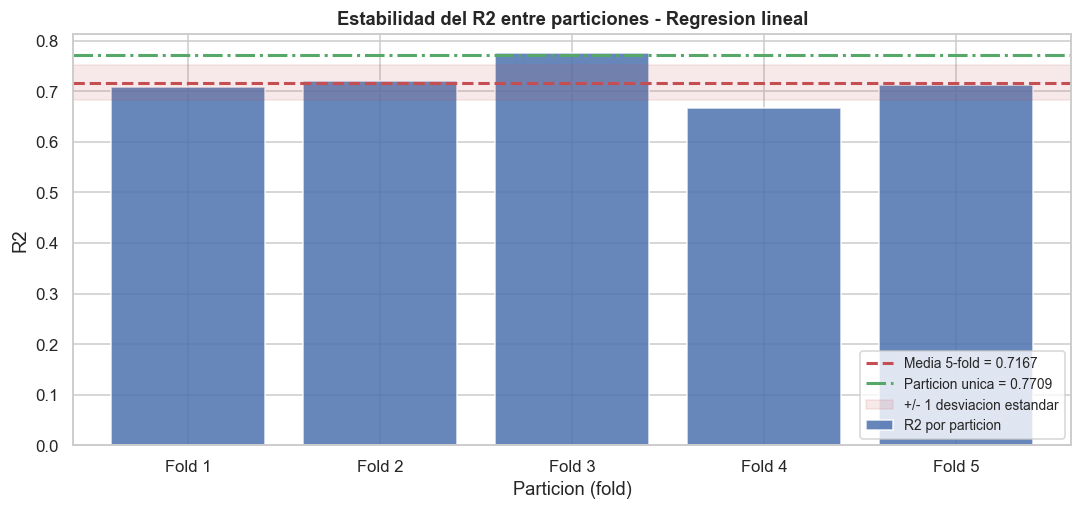

In [27]:
r2_simple = r2_score(y_test, pred_mejor)

print('=' * 66)
print('COMPARACION: PARTICION UNICA vs VALIDACION CRUZADA')
print('=' * 66)
print(f'R2 con una sola particion (80/20) : {r2_simple:.4f}')
print(f'R2 promedio con 5-fold            : {r2_cv.mean():.4f}')
print(f'Diferencia                        : {abs(r2_simple - r2_cv.mean()):.4f}')
print(f'Desviacion estandar entre folds   : {r2_cv.std():.4f}')
print(f'Rango observado entre folds       : '
      f'[{r2_cv.min():.4f} , {r2_cv.max():.4f}]  '
      f'(amplitud de {r2_cv.max() - r2_cv.min():.4f})')

# VISUALIZACION 8: estabilidad de la validacion cruzada
plt.figure(figsize=(10, 4.8))
plt.bar(range(1, 6), r2_cv, color='#4C72B0', edgecolor='white',
        alpha=0.85, label='R2 por particion')
plt.axhline(r2_cv.mean(), color='#C44E52', linestyle='--', linewidth=2,
            label=f'Media 5-fold = {r2_cv.mean():.4f}')
plt.axhline(r2_simple, color='#55A868', linestyle='-.', linewidth=2,
            label=f'Particion unica = {r2_simple:.4f}')
plt.fill_between([0.4, 5.6], r2_cv.mean() - r2_cv.std(), r2_cv.mean() + r2_cv.std(),
                 color='#C44E52', alpha=0.12, label='+/- 1 desviacion estandar')
plt.xlim(0.4, 5.6)
plt.title(f'Estabilidad del R2 entre particiones - {nombre_mejor}',
          fontsize=12, fontweight='bold')
plt.xlabel('Particion (fold)'); plt.ylabel('R2')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

### 12.1 Por qué la validación cruzada ofrece una referencia más estable

**Una sola partición entrega un número sin margen de error.** No informa si ese resultado es
típico o si dependió de la suerte del reparto. Es una fotografía tomada desde un único ángulo.

**La validación cruzada entrega una media y una desviación estándar.** La media promedia cinco
evaluaciones independientes, reduciendo el peso de cualquier reparto afortunado o desafortunado. La
desviación estándar es igual de valiosa: cuantifica **cuánto varía** el desempeño según los datos
que le toquen.

Esa desviación permite distinguir dos situaciones que un número aislado confunde:

| Desviación entre folds | Lectura |
|---|---|
| **Baja** | El modelo es estable; su desempeño no depende de la partición y la estimación es confiable |
| **Alta** | El modelo es sensible a los datos que recibe; el resultado de una sola partición sería poco fiable |

Hay además una razón de **aprovechamiento de los datos**: con una partición 80/20, el 20 % de prueba
nunca se usa para entrenar. Con 5-fold, cada registro sirve para entrenar en cuatro rondas y para
evaluar en una. Se extrae más información del mismo conjunto.

**Qué reveló la comparación en este caso.** La partición única arrojó un R² de 0.7709, mientras que
la media de las cinco particiones fue de 0.7167. La diferencia de 0.054 equivale a **más de una
desviación estándar y media** entre folds, y los valores individuales oscilaron entre 0.6674 y
0.7747: una amplitud de casi 11 puntos porcentuales.

La conclusión es directa: **la partición original resultó ser de las favorables**. Reportar
únicamente ese 0.7709 habría sobrestimado el desempeño real del modelo. La estimación honesta es
**R² ≈ 0.72 ± 0.03**, no 0.77.

Éste es exactamente el motivo por el que la validación cruzada no es un trámite: sin ella, se habría
comunicado un resultado optimista sin ninguna forma de detectarlo.

---

## 13. Variables más relevantes según el modelo

In [28]:
nombres_var = modelo_cv.named_steps['preprocesamiento'].get_feature_names_out()
nombres_var = [n.split('__', 1)[-1] for n in nombres_var]
coeficientes = modelo_cv.named_steps['modelo'].coef_

importancia = pd.DataFrame({
    'Variable': nombres_var,
    'Coeficiente': coeficientes.round(4),
    'Magnitud': np.abs(coeficientes).round(4),
}).sort_values('Magnitud', ascending=False).reset_index(drop=True)

print('Como todas las predictoras fueron escaladas, los coeficientes son')
print('DIRECTAMENTE COMPARABLES entre si. Cada uno indica cuantos puntos de')
print('Exam_Score cambia la prediccion al aumentar esa variable en una')
print('desviacion estandar, manteniendo el resto constante.\n')
importancia

Como todas las predictoras fueron escaladas, los coeficientes son
DIRECTAMENTE COMPARABLES entre si. Cada uno indica cuantos puntos de
Exam_Score cambia la prediccion al aumentar esa variable en una
desviacion estandar, manteniendo el resto constante.



,Variable,Coeficiente,Magnitud
0,Attendance,2.2917,2.2917
1,Hours_Studied,1.7555,1.7555
2,Internet_Access_Yes,0.9581,0.9581
3,Learning_Disabilities_Yes,-0.8538,0.8538
4,Access_to_Resources,0.7313,0.7313
5,Previous_Scores,0.7078,0.7078
6,Parental_Involvement,0.6994,0.6994
7,Tutoring_Sessions,0.6266,0.6266
8,Extracurricular_Activities_Yes,0.5774,0.5774
9,Family_Income,0.4001,0.4001


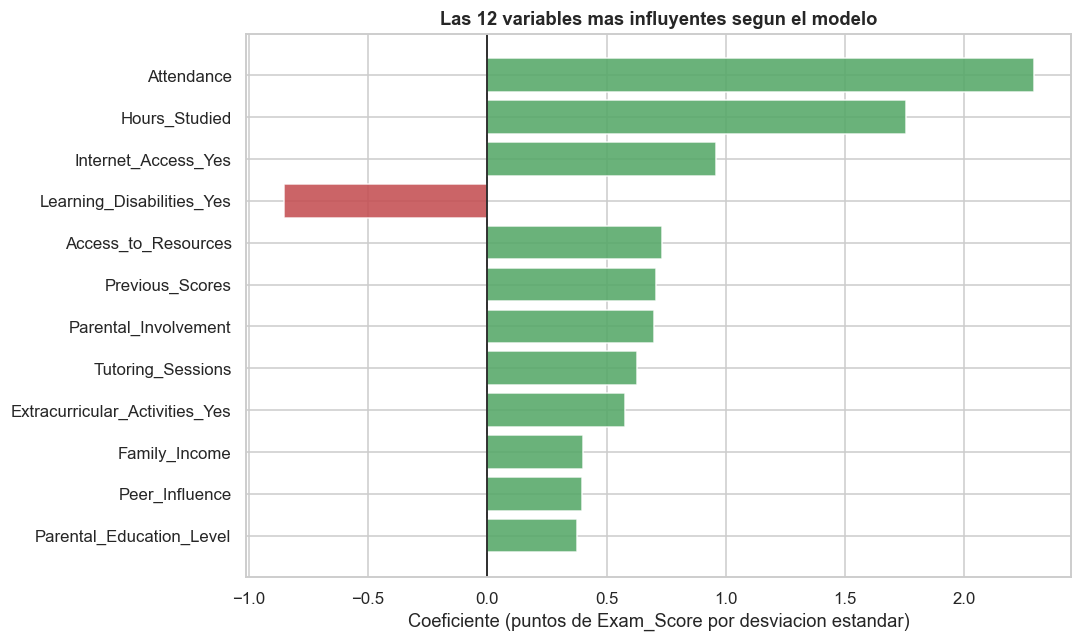

Verde = aumenta la calificacion | Rojo = la disminuye

LAS 5 VARIABLES MAS INFLUYENTES
  Attendance                       +2.2917  (aumenta la calificacion)
  Hours_Studied                    +1.7555  (aumenta la calificacion)
  Internet_Access_Yes              +0.9581  (aumenta la calificacion)
  Learning_Disabilities_Yes        -0.8538  (disminuye la calificacion)
  Access_to_Resources              +0.7313  (aumenta la calificacion)

LAS 5 VARIABLES MENOS INFLUYENTES
  Distance_from_Home               -0.3118
  Physical_Activity                +0.1977
  Gender_Male                      -0.0255
  Sleep_Hours                      -0.0186
  School_Type_Public               +0.0167


In [29]:
# VISUALIZACION 9: importancia de las variables
top = importancia.head(12).iloc[::-1]
plt.figure(figsize=(10, 6))
colores_barra = ['#55A868' if c > 0 else '#C44E52' for c in top['Coeficiente']]
plt.barh(top['Variable'], top['Coeficiente'], color=colores_barra,
         edgecolor='white', alpha=0.88)
plt.axvline(0, color='black', linewidth=1)
plt.title('Las 12 variables mas influyentes segun el modelo',
          fontsize=12, fontweight='bold')
plt.xlabel('Coeficiente (puntos de Exam_Score por desviacion estandar)')
plt.tight_layout(); plt.show()

print('Verde = aumenta la calificacion | Rojo = la disminuye\n')
print('LAS 5 VARIABLES MAS INFLUYENTES')
print('=' * 66)
for _, f in importancia.head(5).iterrows():
    signo = 'aumenta' if f['Coeficiente'] > 0 else 'disminuye'
    print(f'  {f["Variable"]:32s} {f["Coeficiente"]:+.4f}  ({signo} la calificacion)')

print('\nLAS 5 VARIABLES MENOS INFLUYENTES')
print('=' * 66)
for _, f in importancia.tail(5).iterrows():
    print(f'  {f["Variable"]:32s} {f["Coeficiente"]:+.4f}')

---

## 14. Conclusión

### Qué modelo obtuvo mejores resultados

La **regresión lineal** y **Ridge** alcanzaron un desempeño prácticamente idéntico, con diferencias
que aparecen sólo en el cuarto decimal. Ese empate no es casual y resulta informativo: la
regularización de Ridge corrige el sobreajuste y la multicolinealidad, y la sección 4 ya había
mostrado que **este conjunto no padece ninguno de los dos problemas** — la correlación entre
predictoras es cercana a cero, y con 5,285 registros de entrenamiento para 19 variables hay datos de
sobra para estimar los coeficientes con estabilidad.

El árbol de decisión, probado en la sección 11, obtuvo un desempeño **inferior**. Esto confirma lo
que anticipaban los diagramas de dispersión: las relaciones son fundamentalmente lineales, y añadir
flexibilidad al modelo sólo introduce varianza sin capturar estructura adicional.

**Conclusión práctica: se elige la regresión lineal**, por ofrecer el mismo desempeño que Ridge con
mayor simplicidad e interpretabilidad directa de sus coeficientes.

### Cuánto mejoró respecto de la línea base

La mejora es sustancial. El **MAE cae de 2.82 a 0.44 puntos**, una reducción del **84.3 %**, y el
**R² pasa de −0.001 a 0.771**: de no explicar absolutamente nada a explicar el 77 % de la varianza en
la partición de prueba (72 % según la validación cruzada, que es la cifra más honesta).

En términos prácticos: la línea base se equivoca en promedio por casi 3 puntos, mientras que el
modelo lo hace por menos de medio punto.

Esta comparación era **indispensable** en este caso concreto. Dado que `Exam_Score` tiene una
desviación estándar de apenas 3.9 puntos, cualquier modelo produciría errores de aspecto pequeño en
términos absolutos. Sin la línea base sería imposible distinguir entre un modelo que realmente
aprendió y uno que simplemente se beneficia de una variable poco dispersa.

### Qué variables resultaron más relevantes

`Attendance` (+2.29) y `Hours_Studied` (+1.76) dominan con claridad, y su ventaja sobre el resto es
amplia: el tercer predictor, `Internet_Access` (+0.96), pesa menos de la mitad que el segundo. Es un
resultado coherente con la intuición pedagógica: **asistir a clase y dedicar tiempo al estudio** son,
por mucho, los factores con mayor peso sobre el resultado del examen.

Detrás aparecen `Learning_Disabilities` (−0.85, el efecto negativo más fuerte) y
`Access_to_Resources` (+0.73), ambos coherentes con lo esperado.

En el extremo opuesto, variables como `Gender`, `School_Type` o `Sleep_Hours` presentaron
coeficientes cercanos a cero. Conviene subrayar que este hallazgo **es un resultado, no un fracaso**:
haberlas conservado permitió que el modelo demostrara su irrelevancia con evidencia, en lugar de
descartarlas por suposición.

### Limitaciones identificadas

1. **Origen sintético de los datos.** Es la limitación de mayor peso. Las relaciones aprendidas
   reflejan el diseño del generador, no evidencia empírica sobre estudiantes reales.
2. **Fallo severo y sistemático en los alumnos de alto rendimiento.** Es la limitación mejor
   documentada. El modelo acierta dentro de ±2 puntos en el 99.5 % de los casos, pero subestima por
   entre 15 y 28 puntos a 7 alumnos del extremo superior. En el conjunto de prueba sólo hay 9
   alumnos por encima de 75 puntos, de modo que no existen ejemplos suficientes para aprender ese
   tramo. Un modelo que falla justo en los casos excepcionales es poco útil si el propósito fuera
   precisamente identificarlos.
3. **Variables ausentes.** El techo del R² indica que una parte relevante de la variabilidad depende
   de factores no registrados: aptitud individual, calidad del estudio más allá de su duración,
   condiciones del día del examen.
4. **Ausencia de dimensión temporal.** El conjunto es una fotografía única, por lo que **no permite
   establecer causalidad**. Que la asistencia correlacione con la calificación no demuestra que
   obligar a asistir eleve el rendimiento.
5. **Techo de escala no restringido.** El modelo puede predecir valores superiores a 100, que
   carecen de sentido y deberían recortarse en producción.

### Qué cambio se propondría para una etapa posterior

**Prioridad alta — atender la cola derecha.** Es el fallo mejor documentado. Dos vías: aplicar una
transformación logarítmica a la variable objetivo para reducir su asimetría, o entrenar con pesos
que penalicen más el error en los casos de alto rendimiento.

**Prioridad media — probar modelos de conjunto.** Random Forest o Gradient Boosting capturan
interacciones entre variables (por ejemplo, que las horas de estudio rindan más cuando hay buen
acceso a recursos) que un modelo lineal no puede representar.

**Prioridad media — ingeniería de características.** Construir variables derivadas como
`Hours_Studied × Access_to_Resources`, o una razón entre asistencia y horas de estudio.

**Prioridad baja — ajuste de hiperparámetros** mediante `GridSearchCV` con validación cruzada
anidada.

### ¿Es suficiente como primera aproximación?

**Como ejercicio académico y primera aproximación: sí.** El flujo está completo y es reproducible,
supera con claridad la línea base, no presenta fuga de información y sus limitaciones están
identificadas con evidencia.

**Para apoyar decisiones académicas reales: no, y por un margen amplio.** Tres razones lo impiden:

Primero, **los datos son sintéticos**. Cualquier conclusión sobre estudiantes reales carecería de
fundamento, con independencia de lo buenas que sean las métricas.

Segundo, **el modelo falla justamente donde más importaría**. Un sistema de detección de riesgo
académico necesita identificar bien los casos extremos, y este modelo es más impreciso precisamente
en ellos.

Tercero, y más importante, **correlación no es causalidad**. El modelo detecta que la asistencia se
asocia con mejores calificaciones, pero no demuestra que aumentarla las produzca. Usarlo para
justificar políticas institucionales sería un error metodológico grave.

**Recomendación:** antes de cualquier uso real, sería necesario validar el flujo sobre **datos
reales de estudiantes**, verificar que el patrón persiste y complementar el análisis con métodos de
inferencia causal. El valor de este trabajo reside en haber dejado el procedimiento montado y
verificado, listo para aplicarse cuando existan datos que sí lo justifiquen.

---

### Fuentes consultadas

- Abdel-Ghany, M. (2025). *Student Performance Factors Dataset* [Conjunto de datos]. Kaggle.
  https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset
- Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine
  Learning Research, 12*, 2825–2830. https://scikit-learn.org/stable/
- The pandas development team. (2024). *pandas-dev/pandas: Pandas*. https://pandas.pydata.org/docs/
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science &
  Engineering, 9*(3), 90–95. https://matplotlib.org/